# Occupation Similarity Analysis
Per-domain and cumulative cosine similarity between O*NET occupations, with hierarchical clustering visualization.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from similarity import compute_similarity_matrices, most_similar

PROCESSED = Path('../data/processed')

## 1. Load master dataframe

In [2]:
master = pd.read_parquet(PROCESSED / 'onet_master.parquet')
print(f"{len(master):,} occupations, {master.shape[1]:,} columns")

1,016 occupations, 445 columns


## 2. Compute similarity matrices (per domain + cumulative)

In [3]:
matrices = compute_similarity_matrices(master)

print("Similarity matrices computed:")
for domain, mat in matrices.items():
    print(f"  {domain}: {mat.shape}")

Similarity matrices computed:
  ability: (1016, 1016)
  skill: (1016, 1016)
  knowledge: (1016, 1016)
  work_activity: (1016, 1016)
  work_style: (1016, 1016)
  work_value: (1016, 1016)
  interest: (1016, 1016)
  work_context: (1016, 1016)
  cumulative: (1016, 1016)


## 3. Most-similar query
Change `QUERY_JOB` to any O\*NET title or SOC code.

In [4]:
# ── configure here ──────────────────────────────────────────
QUERY_JOB = 'Software Developers'   # title substring or exact SOC code
TOP_N     = 15
# ────────────────────────────────────────────────────────────

# Resolve to a SOC code
title_col = master['title'].str.lower()
matches = master[title_col.str.contains(QUERY_JOB.lower(), regex=False)]
if len(matches) == 0:
    # Try as SOC code
    matches = master[master['soc_code'] == QUERY_JOB]

if len(matches) == 0:
    raise ValueError(f"No occupation found matching '{QUERY_JOB}'")

query_soc  = matches.iloc[0]['soc_code']
query_title = matches.iloc[0]['title']
print(f"Query: {query_title} ({query_soc})")
if len(matches) > 1:
    print(f"  (multiple matches found — using first. Others: {matches['title'].tolist()[1:3]})")

Query: Software Developers (15-1252.00)


In [5]:
results = most_similar(query_soc, matrices, master, top_n=TOP_N)

# Format for display
display_cols = ['title', 'job_zone', 'cumulative'] + \
               [c for c in results.columns if c not in ('title', 'job_zone', 'cumulative')]
results[display_cols].style \
    .background_gradient(subset=['cumulative'], cmap='YlOrRd') \
    .format({c: '{:.4f}' for c in display_cols if c not in ('title', 'job_zone')})

,title,job_zone,cumulative,ability,skill,knowledge,work_activity,work_style,work_value,interest,work_context
soc_code,,,,,,,,,,,
15-1211.00,Computer Systems Analysts,3.000000,0.6676,0.7109,0.8523,0.8049,0.5787,0.7333,0.0000,0.9811,0.6799
15-1253.00,Software Quality Assurance Analysts and Testers,4.000000,0.6338,0.8153,0.8271,0.7871,0.6030,0.4485,0.0000,0.9524,0.6367
15-1221.00,Computer and Information Research Scientists,5.000000,0.6244,0.7383,0.8231,0.5174,0.5016,0.8543,0.0000,0.9046,0.6561
15-1243.00,Database Architects,4.000000,0.6222,0.8669,0.9128,0.7384,0.4752,0.7624,0.0000,0.4887,0.7332
15-2099.01,Bioinformatics Technicians,4.000000,0.6167,0.6821,0.6802,0.4542,0.6528,0.7305,0.0000,0.9345,0.7997
15-1243.01,Data Warehousing Specialists,4.000000,0.6167,0.9187,0.8592,0.8386,0.7018,0.4811,0.0000,0.3843,0.7499
15-1254.00,Web Developers,3.000000,0.6116,0.7821,0.8906,0.6630,0.6988,0.8435,0.0000,0.3118,0.7032
15-1242.00,Database Administrators,4.000000,0.5972,0.8542,0.8398,0.7623,0.6549,0.4887,-0.0000,0.3783,0.7992
15-2031.00,Operations Research Analysts,5.000000,0.5900,0.8258,0.4942,0.6036,0.4360,0.7190,0.0000,0.9086,0.7326


## 4. Domain contribution breakdown (bar chart)
Shows which domains drive the similarity for the top matches.

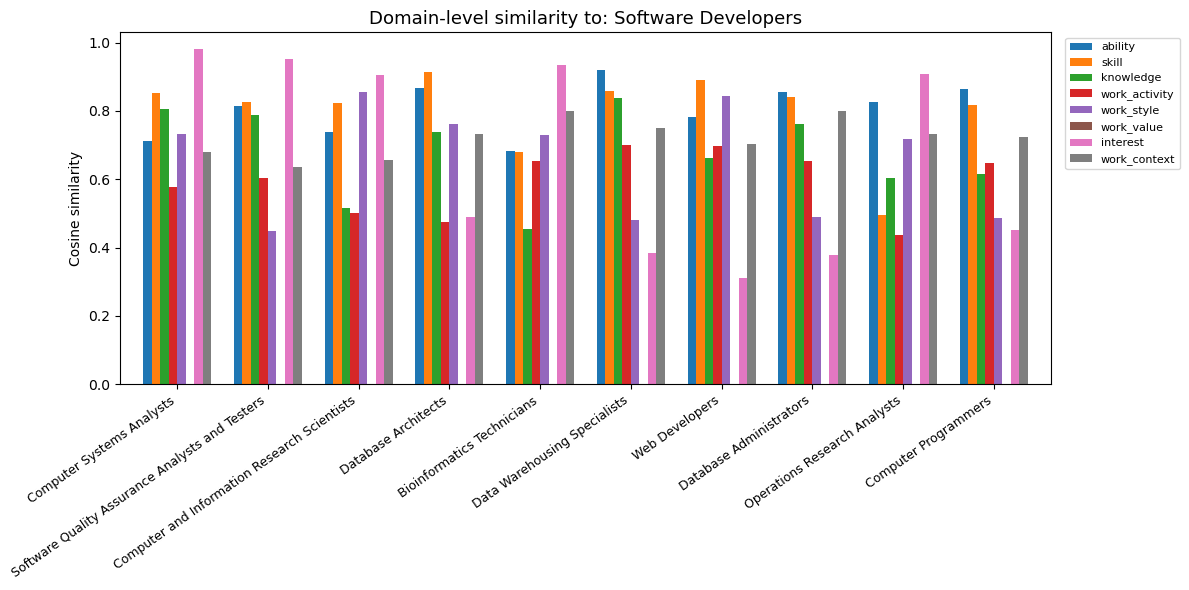

In [6]:
domain_cols = [c for c in results.columns if c not in ('title', 'job_zone', 'cumulative')]
top10 = results.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top10[domain_cols].set_index(top10['title']).plot(
    kind='bar', ax=ax, width=0.75
)
ax.set_title(f'Domain-level similarity to: {query_title}', fontsize=13)
ax.set_ylabel('Cosine similarity')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(PROCESSED / f'domain_similarity_{query_soc.replace("/","-")}.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Hierarchical clustering on full occupation set
Uses the cumulative similarity matrix. We convert similarity to distance (1 − sim) and run Ward linkage.

In [7]:
cum_sim = matrices['cumulative'].values

# Similarity → distance, clamp to [0,1] to avoid floating point negatives
dist_matrix = np.clip(1 - cum_sim, 0, 2)
np.fill_diagonal(dist_matrix, 0)

condensed = squareform(dist_matrix)
Z = linkage(condensed, method='ward')

# Assign cluster labels (tune n_clusters as needed)
N_CLUSTERS = 20
cluster_labels = fcluster(Z, t=N_CLUSTERS, criterion='maxclust')

master_clustered = master[['soc_code', 'title', 'job_zone', 'required_education_level']].copy()
master_clustered['cluster'] = cluster_labels

print(f"Cluster sizes:")
print(master_clustered['cluster'].value_counts().sort_index().to_string())

Cluster sizes:
1      46
2      35
3      63
4      52
5     146
6      45
7      47
8      35
9      34
10     61
11     49
12     52
13     51
14     33
15    122
16     26
17     45
18     41
19     12
20     21


In [8]:
# Show representative titles per cluster (top 5 by alphabetical for now)
for cluster_id in sorted(master_clustered['cluster'].unique()):
    titles = master_clustered[master_clustered['cluster'] == cluster_id]['title'].sort_values().head(5).tolist()
    print(f"Cluster {cluster_id:2d}: {', '.join(titles)}")

Cluster  1: Billing and Posting Clerks, Bookkeeping, Accounting, and Auditing Clerks, Brokerage Clerks, Compliance Officers, Correspondence Clerks
Cluster  2: Amusement and Recreation Attendants, Animal Caretakers, Baggage Porters and Bellhops, Baristas, Bartenders
Cluster  3: Aircraft Structure, Surfaces, Rigging, and Systems Assemblers, Audiovisual Equipment Installers and Repairers, Automotive Service Technicians and Mechanics, Bicycle Repairers, Biofuels Processing Technicians
Cluster  4: Agricultural Equipment Operators, Animal Breeders, Bakers, Bridge and Lock Tenders, Butchers and Meat Cutters
Cluster  5: Adhesive Bonding Machine Operators and Tenders, Agricultural Technicians, Automotive Body and Related Repairers, Automotive Glass Installers and Repairers, Automotive and Watercraft Service Attendants
Cluster  6: Acute Care Nurses, Advanced Practice Psychiatric Nurses, Allergists and Immunologists, Anesthesiologists, Athletic Trainers
Cluster  7: Acupuncturists, Adapted Physica

## 6. Clustermap: similarity heatmap of a focused subset
Too many jobs to show all 1,016. We pick either:
- The cluster(s) containing the query job, or
- A custom list of SOC codes / title substrings.

In [9]:
# ── configure here ──────────────────────────────────────────
# 'auto'   → use the cluster(s) of the query job above
# 'custom' → use CUSTOM_FILTER (list of title substrings)
CLUSTERMAP_MODE   = 'auto'
CUSTOM_FILTER     = ['Engineer', 'Developer', 'Analyst', 'Architect']
MAX_JOBS_IN_MAP   = 60   # cap to keep the chart readable
# ────────────────────────────────────────────────────────────

if CLUSTERMAP_MODE == 'auto':
    query_cluster = master_clustered.loc[
        master_clustered['soc_code'] == query_soc, 'cluster'
    ].iloc[0]
    subset_socs = master_clustered[
        master_clustered['cluster'] == query_cluster
    ]['soc_code'].tolist()
    print(f"Query job is in cluster {query_cluster} ({len(subset_socs)} occupations)")
else:
    pattern = '|'.join(CUSTOM_FILTER)
    subset_socs = master[
        master['title'].str.contains(pattern, case=False, na=False)
    ]['soc_code'].tolist()
    print(f"{len(subset_socs)} occupations matching custom filter")

# Cap size
if len(subset_socs) > MAX_JOBS_IN_MAP:
    # Keep the most central ones (highest mean similarity within subset)
    sub_sim = matrices['cumulative'].loc[subset_socs, subset_socs]
    mean_sim = sub_sim.mean(axis=1).sort_values(ascending=False)
    subset_socs = mean_sim.head(MAX_JOBS_IN_MAP).index.tolist()
    print(f"Trimmed to top {MAX_JOBS_IN_MAP} most central jobs")

# Build the subset similarity matrix with short labels
title_map = master.set_index('soc_code')['title'].to_dict()
sub_sim = matrices['cumulative'].loc[subset_socs, subset_socs].copy()
sub_sim.index   = [title_map[s] for s in sub_sim.index]
sub_sim.columns = [title_map[s] for s in sub_sim.columns]

print(f"Plotting clustermap for {len(subset_socs)} occupations...")

Query job is in cluster 9 (34 occupations)
Plotting clustermap for 34 occupations...


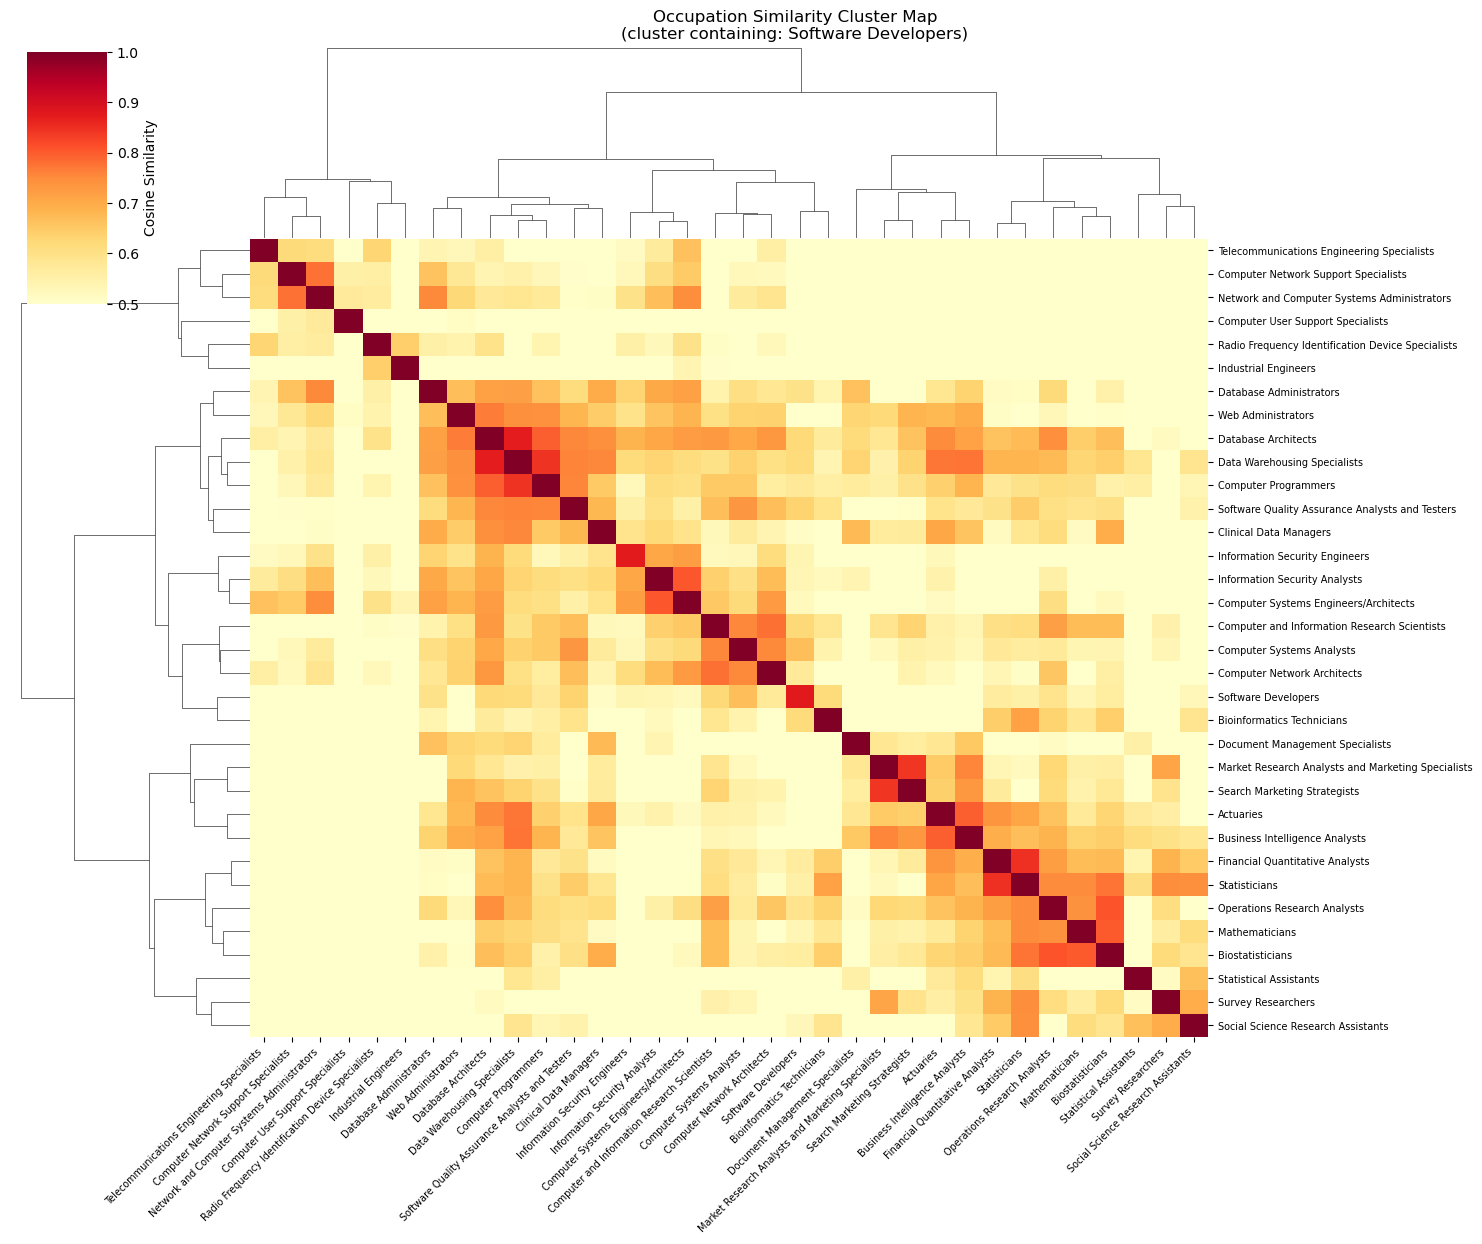

Saved to reports/


In [10]:
g = sns.clustermap(
    sub_sim,
    method='ward',
    cmap='YlOrRd',
    figsize=(16, 14),
    xticklabels=True,
    yticklabels=True,
    vmin=0.5,
    vmax=1.0,
    linewidths=0,
    cbar_kws={'label': 'Cosine Similarity'},
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=7
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7
)
g.figure.suptitle(
    f'Occupation Similarity Cluster Map\n(cluster containing: {query_title})',
    y=1.01, fontsize=12
)
plt.savefig(
    PROCESSED / f'clustermap_{query_soc.replace("/","-")}.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved to reports/")

## 7. Save outputs

In [11]:
# Save cluster assignments
master_clustered.to_parquet(PROCESSED / 'onet_clusters.parquet', index=False)

# Save the most-similar results for the query job
results.to_csv(
    PROCESSED / f'similar_to_{query_soc.replace("/","-")}.csv'
)

print("Saved:")
print(f"  data/processed/onet_clusters.parquet")
print(f"  data/processed/similar_to_{query_soc.replace('/','-')}.csv")

Saved:
  data/processed/onet_clusters.parquet
  data/processed/similar_to_15-1252.00.csv
